**Sobre este conjunto de dados**

O Índice Global de Crise de Saúde Mental 2026 é um conjunto de dados transnacional que abrange 92 países em todas as seis regiões da OMS, fornecendo um panorama abrangente do estado da saúde mental em todo o mundo em 2025. Ele combina indicadores epidemiológicos, econômicos, políticos e de comportamento digital em um único arquivo pronto para análise, sem valores ausentes.

**Fontes de dados**

**Os dados foram compilados e harmonizados a partir de:**

- Atlas de Saúde Mental da OMS 2024
- Estudo da Carga Global de Doenças 2023 (IHME)
- Nosso Mundo em Dados (acessado em março de 2026)
- Estatísticas de Saúde da OCDE 2024
- Relatório de Dados 2025

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset = pd.read_csv ('Global_Mental_Health_Crisis_Index_2026.csv')

In [ ]:
dataset.columns

Traduzindo os nomes das colunas para melhor compreensão

In [9]:
dataset.columns = ['pais', 'iso3', 'regiao', 'grupo_renda', 'depressao_pct',
'ansiedade_pct', 'taxa_suicidio_por_100mil', 'psiquiatras_por_100mil',
'orcamento_sm_pct_saude', 'gasto_sm_usd_per_capita', 'lacuna_tratamento_pct',
'horas_diarias_redes_sociais', 'penetracao_internet_pct',
'pib_per_capita_usd', 'populacao_milhoes', 'aumento_sm_covid_pct',
'score_crise_sm_jovens', 'existe_politica_sm', 'existe_lei_sm',
'indice_crise_sm', 'total_afetados_milhoes',
'psiquiatras_por_milhao', 'lacuna_investimento_sm',
'risco_sm_redes_sociais', 'est_comorbidade_depressao_ansiedade_pct',
'score_sistema_sm', 'codigo_grupo_renda', 'ano_dados', 'fonte_dados']

In [ ]:
dataset.pais

**1° Caso de uso - Redes sociais e saúde mental — exploraremos a relação entre o tempo gasto em frente às telas e os índices de depressão/ansiedade.**

In [27]:
colunas_analise = ['pais', 'horas_diarias_redes_sociais', 'depressao_pct', 'ansiedade_pct', 'regiao', 'taxa_suicidio_por_100mil']

In [28]:
colunas_analise = ['pais', 'horas_diarias_redes_sociais', 'depressao_pct', 'ansiedade_pct', 'regiao','taxa_suicidio_por_100mil']
df_sm = dataset[colunas_analise].copy()

In [29]:
df_sm = df_sm.dropna()

In [ ]:
print(df_sm.info())
print(df_sm.describe())

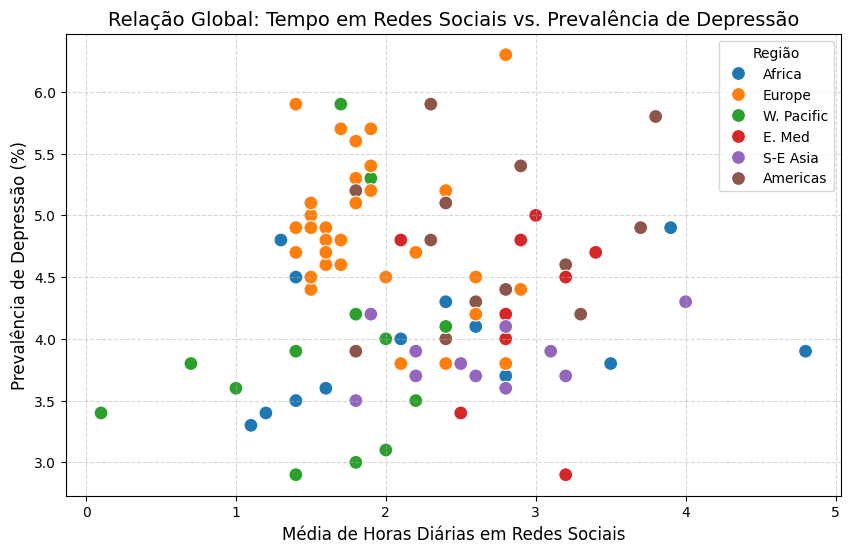

In [23]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_sm, x='horas_diarias_redes_sociais', y='depressao_pct', hue='regiao', s=100)

plt.title('Relação Global: Tempo em Redes Sociais vs. Prevalência de Depressão', fontsize=14)
plt.xlabel('Média de Horas Diárias em Redes Sociais', fontsize=12)
plt.ylabel('Prevalência de Depressão (%)', fontsize=12)
plt.legend(title='Região')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

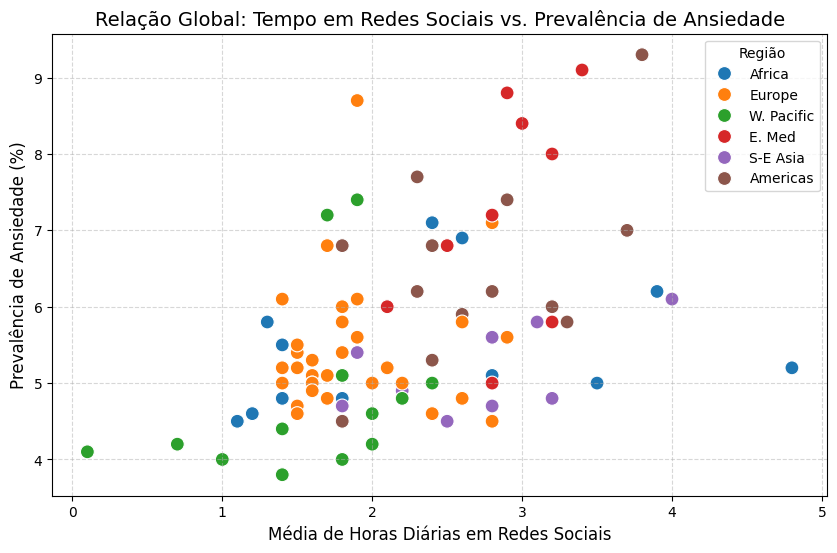

In [26]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_sm, x='horas_diarias_redes_sociais', y='ansiedade_pct', hue='regiao', s=100)

plt.title('Relação Global: Tempo em Redes Sociais vs. Prevalência de Ansiedade', fontsize=14)
plt.xlabel('Média de Horas Diárias em Redes Sociais', fontsize=12)
plt.ylabel('Prevalência de Ansiedade (%)', fontsize=12)
plt.legend(title='Região')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

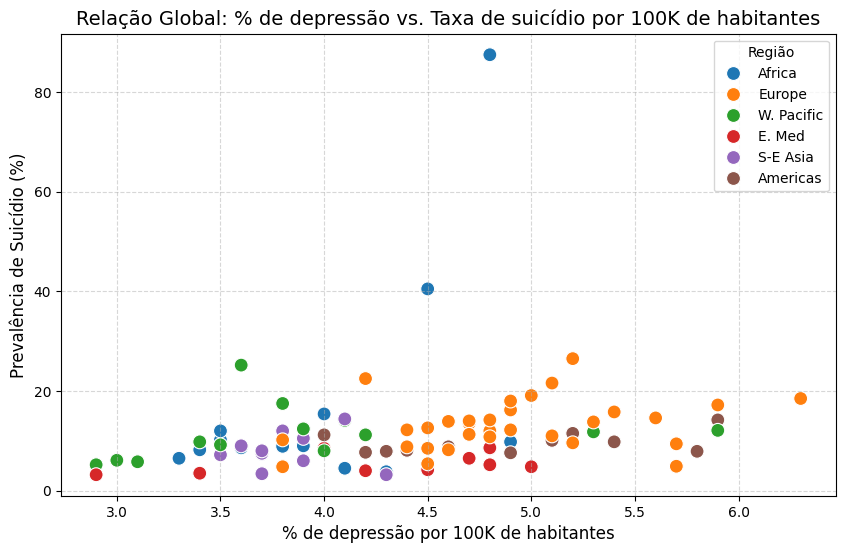

In [32]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_sm, x='depressao_pct', y='taxa_suicidio_por_100mil', hue='regiao', s=100)

plt.title('Relação Global: % de depressão vs. Taxa de suicídio por 100K de habitantes', fontsize=14)
plt.xlabel('% de depressão por 100K de habitantes', fontsize=12)
plt.ylabel('Prevalência de Suicídio (%)', fontsize=12)
plt.legend(title='Região')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

**2° Caso de uso - Pesquisa sobre desigualdade — comparação das disparidades no acesso a cuidados de saúde entre países de alta e baixa renda.**

In [34]:
resumo_desigualdade = dataset.groupby('grupo_renda')[[
    'psiquiatras_por_100mil',
    'orcamento_sm_pct_saude',
    'lacuna_tratamento_pct'
]].mean().sort_values('psiquiatras_por_100mil', ascending=False)

/tmp/ipykernel_11422/700659158.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dataset, x='grupo_renda', y='lacuna_tratamento_pct', palette='viridis', errorbar=None)


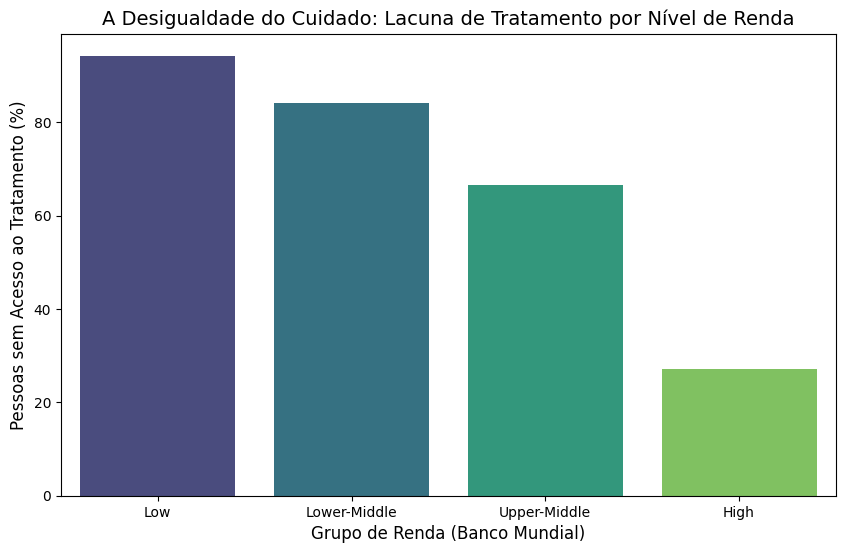

In [36]:
plt.figure(figsize=(10, 6))
sns.barplot(data=dataset, x='grupo_renda', y='lacuna_tratamento_pct', palette='viridis', errorbar=None)

plt.title('A Desigualdade do Cuidado: Lacuna de Tratamento por Nível de Renda', fontsize=14)
plt.xlabel('Grupo de Renda (Banco Mundial)', fontsize=12)
plt.ylabel('Pessoas sem Acesso ao Tratamento (%)', fontsize=12)
plt.show()

Porcentagem de países com leis de saúde mental por grupo de renda:
existe_lei_sm          No         Yes
grupo_renda                          
High             0.000000  100.000000
Low            100.000000    0.000000
Lower-Middle    50.000000   50.000000
Upper-Middle    13.043478   86.956522


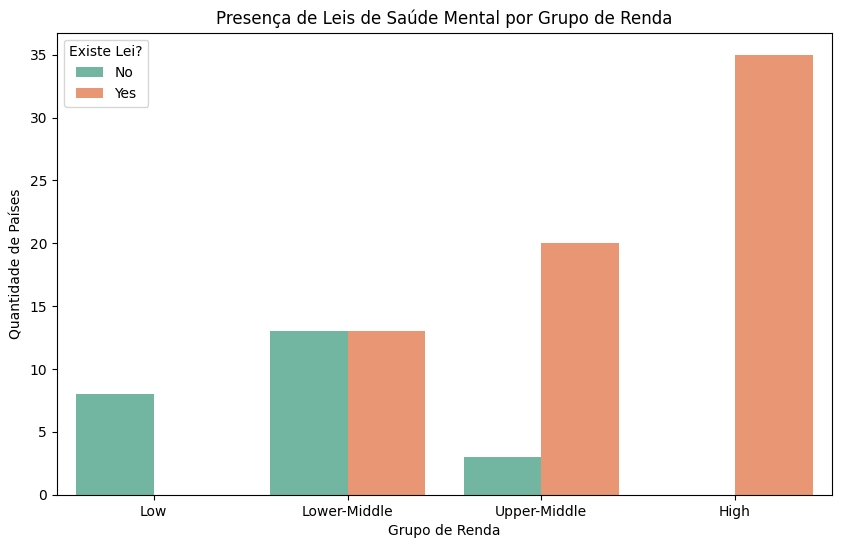

In [37]:
tabela_leis = pd.crosstab(dataset['grupo_renda'], dataset['existe_lei_sm'], normalize='index') * 100

print("Porcentagem de países com leis de saúde mental por grupo de renda:")
print(tabela_leis)

plt.figure(figsize=(10, 6))
sns.countplot(data=dataset, x='grupo_renda', hue='existe_lei_sm', palette='Set2')
plt.title('Presença de Leis de Saúde Mental por Grupo de Renda')
plt.xlabel('Grupo de Renda')
plt.ylabel('Quantidade de Países')
plt.legend(title='Existe Lei?')
plt.show()

/tmp/ipykernel_11422/2153245202.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


([0, 1, 2, 3],
 [Text(0, 0, 'Low'),
  Text(1, 0, 'Lower-Middle'),
  Text(2, 0, 'Upper-Middle'),
  Text(3, 0, 'High')])

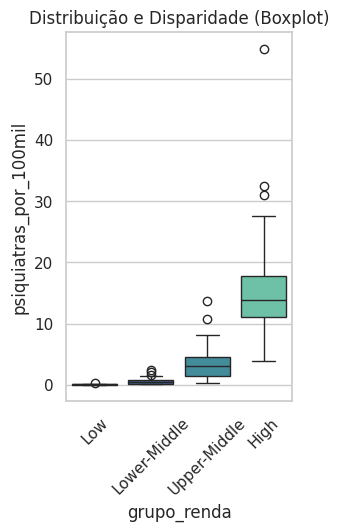

In [43]:
# --- GRÁFICO 2: BOXPLOT (Ver a Desigualdade interna) ---
# O Boxplot mostra onde a maioria dos países está e quem são os "outliers"
plt.subplot(1, 2, 2) # Segundo gráfico
sns.boxplot(
    data=dataset,
    x='grupo_renda',
    y='psiquiatras_por_100mil',
    palette='mako'
)
plt.title('Distribuição e Disparidade (Boxplot)')
plt.xticks(rotation=45)

In [45]:
import plotly.express as px

# Criando um mapa global de Prevalência de Ansiedade
fig = px.choropleth(
    dataset,
    locations="iso3",               # A coluna com os códigos de 3 letras
    color="ansiedade_pct",          # A métrica que define a cor
    hover_name="pais",              # O que aparece ao passar o mouse
    color_continuous_scale=px.colors.sequential.YlOrRd, # Amarelo para Vermelho (alerta)
    title="Prevalência Global de Ansiedade (%)",
    labels={'ansiedade_pct': 'Ansiedade (%)'}
)

fig.update_layout(geo=dict(showframe=False, showcoastlines=True))
fig.show()

In [47]:
fig = px.choropleth(
    dataset,
    locations="iso3",               # A coluna com os códigos de 3 letras
    color="taxa_suicidio_por_100mil",          # A métrica que define a cor
    hover_name="pais",              # O que aparece ao passar o mouse
    color_continuous_scale=px.colors.sequential.YlOrRd, # Amarelo para Vermelho (alerta)
    title="Prevalência Global de Suicídio (%)",
    labels={'taxa_suicidio_por_100mil': 'Suicídio (%)'}
)

fig.update_layout(geo=dict(showframe=False, showcoastlines=True))
fig.show()

In [48]:
fig = px.choropleth(
    dataset,
    locations="iso3",               # A coluna com os códigos de 3 letras
    color="psiquiatras_por_100mil",          # A métrica que define a cor
    hover_name="pais",              # O que aparece ao passar o mouse
    color_continuous_scale=px.colors.sequential.YlOrRd, # Amarelo para Vermelho (alerta)
    title="Prevalência Global de psquiatras por habitantes (%)",
    labels={'ansiedade_pct': 'Ansiedade (%)'}
)

fig.update_layout(geo=dict(showframe=False, showcoastlines=True))
fig.show()

In [49]:
fig = px.choropleth(
    dataset,
    locations="iso3",               # A coluna com os códigos de 3 letras
    color="aumento_sm_covid_pct",          # A métrica que define a cor
    hover_name="pais",              # O que aparece ao passar o mouse
    color_continuous_scale=px.colors.sequential.YlOrRd, # Amarelo para Vermelho (alerta)
    title="Prevalência Global de aumento de doenças mentais pós covid 19",
    labels={'ansiedade_pct': 'Ansiedade (%)'}
)

fig.update_layout(geo=dict(showframe=False, showcoastlines=True))
fig.show()